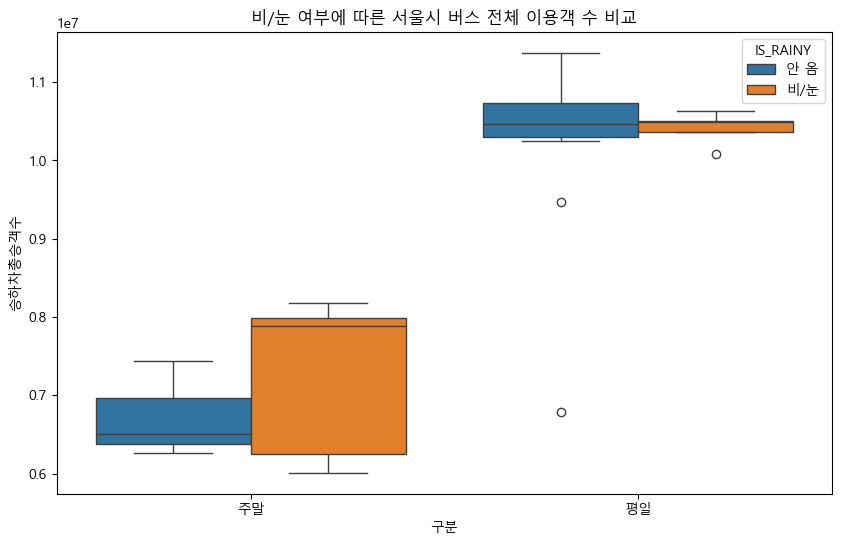

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

plt.rcParams['font.family'] = 'Malgun Gothic'

current_path =os.getcwd()
root = os.path.dirname(os.path.dirname(current_path))

bus_file = os.path.join(root, "data","raw","BUS_STATION_BOARDING_MONTH_202512.csv")
weather_file = os.path.join(root,"data","raw","weather_data_2025.csv")

bus_df = pd.read_csv(bus_file, encoding ='cp949')
weather_df = pd.read_csv(weather_file, encoding ='cp949')

# 다운 데이터는 사용일자 api는 USE_YMD
bus_df['사용일자'] = pd.to_datetime(bus_df["사용일자"], format='%Y%m%d')
weather_df['TM']= pd.to_datetime(weather_df['TM'], format='%Y%m%d')

#서울 지점 번호 108
seoul_weather = weather_df[weather_df['STN']==108].copy()

seoul_weather['RN_DAY']= seoul_weather['RN_DAY'].fillna(0)

day_bus = bus_df.groupby('사용일자')[['승차총승객수','하차총승객수']].sum().reset_index()
day_bus['승하차총승객수'] =  day_bus['승차총승객수']+day_bus['하차총승객수']

merged_df = pd.merge(day_bus,seoul_weather,left_on ='사용일자',right_on = 'TM',how='inner')

merged_df['IS_RAINY'] = merged_df['RN_DAY'].apply(lambda x:"비/눈" if x>0 else "안 옴")

#weekday()의 결과는 0(월)부터 6(일)
merged_df['평일'] = merged_df['사용일자'].dt.weekday.apply(lambda x: '주말' if x>=5 else "평일")
merged_df['평일'] = pd.Categorical(merged_df['평일'])
plt.figure(figsize=(10,6))
# sns.boxplot(x="IS_RAINY", y="승하차총승객수",data=merged_df)
sns.boxplot(x="평일", y="승하차총승객수",hue = "IS_RAINY",data=merged_df)

plt.title('비/눈 여부에 따른 서울시 버스 전체 이용객 수 비교')
plt.xlabel('구분')
plt.ylabel('승하차총승객수')

plt.show()

파이썬이 찾은 파일들: ['BUS_STATION_BOARDING_MONTH_202501.csv', 'BUS_STATION_BOARDING_MONTH_202502.csv', 'BUS_STATION_BOARDING_MONTH_202503.csv', 'BUS_STATION_BOARDING_MONTH_202504.csv', 'BUS_STATION_BOARDING_MONTH_202505.csv', 'BUS_STATION_BOARDING_MONTH_202506.csv', 'BUS_STATION_BOARDING_MONTH_202507.csv', 'BUS_STATION_BOARDING_MONTH_202508.csv', 'BUS_STATION_BOARDING_MONTH_202509.csv', 'BUS_STATION_BOARDING_MONTH_202510.csv', 'BUS_STATION_BOARDING_MONTH_202511.csv', 'BUS_STATION_BOARDING_MONTH_202512.csv', 'CARD_SUBWAY_MONTH_202501.csv', 'CARD_SUBWAY_MONTH_202502.csv', 'CARD_SUBWAY_MONTH_202503.csv', 'CARD_SUBWAY_MONTH_202504.csv', 'CARD_SUBWAY_MONTH_202505.csv', 'CARD_SUBWAY_MONTH_202506.csv', 'CARD_SUBWAY_MONTH_202507.csv', 'CARD_SUBWAY_MONTH_202508.csv', 'CARD_SUBWAY_MONTH_202509.csv', 'CARD_SUBWAY_MONTH_202510.csv', 'CARD_SUBWAY_MONTH_202511.csv', 'CARD_SUBWAY_MONTH_202512.csv', 'weather_data_2023.csv', 'weather_data_2024.csv', 'weather_data_2025.csv']
error:['CARD_SUBWAY_MONTH_202501.cs

C:\Temp\ipykernel_1632\2845119543.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  passanger_avg = melted_df.groupby(["IS_RAINY","교통수단"])['승객수'].mean()


IS_RAINY  교통수단  
많이 옴      버스승객수             NaN
          지하철승객수            NaN
조금 옴      버스승객수      10415640.0
          지하철승객수    124987685.0
안 옴       버스승객수      10325515.0
          지하철승객수    123906177.0
Name: 승객수, dtype: float64
🌧️ 80mm 이상 비가 온 평일 목록:
              TM  RN_DAY
21722 2025-08-13   126.7


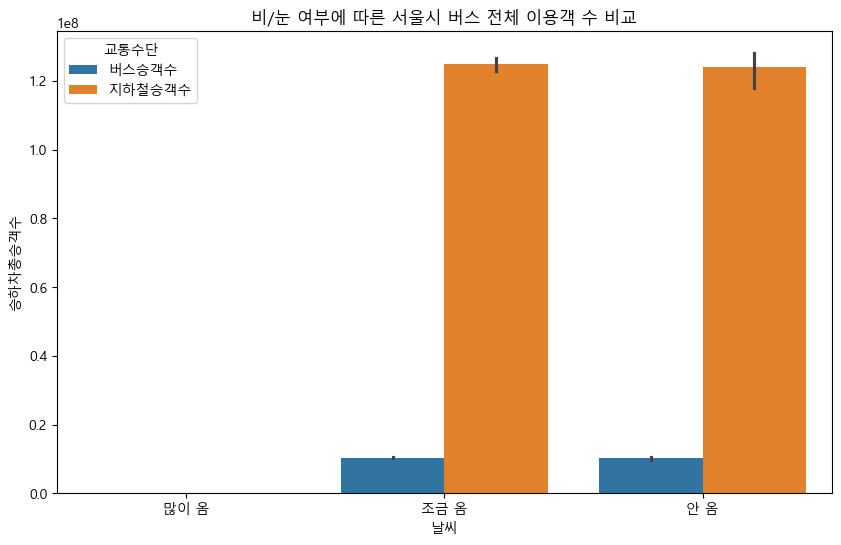

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import chardet

plt.rcParams['font.family'] = 'Malgun Gothic'

def auto_encoding(path):
    with open(path, 'rb') as file:
        raw_data = file.read(100000)
    result = chardet.detect(raw_data)
    print(f"{path}:{result}")
    return result['encoding']
        

current_path =os.getcwd()
root = os.path.dirname(os.path.dirname(current_path))
raw_folder = os.path.join(root, 'data','raw')

raw_files = os.listdir(raw_folder)

print("파이썬이 찾은 파일들:", raw_files)

bus_df_list=[]
subway_df_list=[]

err=[]

for name in raw_files:
    if name.startswith("BUS_STATION_BOARDING_MONTH_"):
        file_path = os.path.join(raw_folder,name)

        temp = pd.read_csv(file_path,encoding='cp949', index_col=False)
        bus_df_list.append(temp)
    
    elif name.startswith("CARD_SUBWAY_MONTH_2025"):
        file_path = os.path.join(raw_folder,name)

        try:
            
            temp = pd.read_csv(file_path, encoding="cp949", index_col=False)
        except UnicodeDecodeError:
            err.append(name)
        subway_df_list.append(temp)
        
        
print(f"error:{err}")
# print(f"subway_list : {subway_df_list}")
bus_df = pd.concat(bus_df_list)
subway_df = pd.concat(subway_df_list)


# bus_files = os.path.join(root, "data","raw","BUS_STATION_BOARDING_MONTH_*.csv")
weather_file = os.path.join(root,"data","raw","weather_data_2025.csv")

# bus_df = pd.read_csv(bus_file, encoding ='cp949')
weather_df = pd.read_csv(weather_file, encoding ='cp949')

# 다운 데이터는 사용일자 api는 USE_YMD
bus_df['사용일자'] = pd.to_datetime(bus_df["사용일자"], format='%Y%m%d')
subway_df['사용일자'] = pd.to_datetime(subway_df["사용일자"], format='%Y%m%d', errors='coerce')
weather_df['TM']= pd.to_datetime(weather_df['TM'], format='%Y%m%d')

#서울 지점 번호 108
seoul_weather = weather_df[weather_df['STN']==108].copy()

seoul_weather['RN_DAY']= seoul_weather['RN_DAY'].fillna(0)

day_bus = bus_df.groupby('사용일자')[['승차총승객수','하차총승객수']].sum().reset_index()
day_bus['버스승객수'] =  day_bus['승차총승객수']+day_bus['하차총승객수']

day_subway = subway_df.groupby('사용일자')[['승차총승객수','하차총승객수']].sum().reset_index()
day_subway['지하철승객수'] =  day_subway['승차총승객수']+day_subway['하차총승객수']

merged_df = pd.merge(day_bus[['사용일자','버스승객수']], seoul_weather, left_on='사용일자',right_on='TM',how="inner")
merged_df = pd.merge(merged_df,day_subway[['사용일자','지하철승객수']],on ='사용일자',how='inner')

def classifition_rain(x):
    if x>=20:
        return "많이 옴"
    elif x>0:
        return "조금 옴"
    else:
        return "안 옴"
merged_df['IS_RAINY'] = merged_df['RN_DAY'].apply(classifition_rain)
merged_df['IS_RAINY'] = pd.Categorical(merged_df['IS_RAINY'],categories=['많이 옴','조금 옴','안 옴'])

#weekday()의 결과는 0(월)부터 6(일)
merged_df['평일'] = merged_df['사용일자'].dt.weekday.apply(lambda x: '주말' if x>=5 else "평일")
merged_df['평일'] = pd.Categorical(merged_df['평일'])
weekday_df = merged_df[merged_df['평일']=='평일'].copy()

melted_df = pd.melt(weekday_df,
                    id_vars=["사용일자","IS_RAINY"],
                    value_vars = ['버스승객수','지하철승객수'],
                    var_name="교통수단",
                    value_name="승객수")
passanger_avg = melted_df.groupby(["IS_RAINY","교통수단"])['승객수'].mean()
print(passanger_avg.round(0))

seoul_weather['평일여부'] = seoul_weather['TM'].dt.weekday.apply(lambda x: '주말' if x >= 5 else "평일")
heavy_rain_days = seoul_weather[(seoul_weather['RN_DAY'] >= 80) & (seoul_weather['평일여부'] == '평일')]

print("🌧️ 80mm 이상 비가 온 평일 목록:")
print(heavy_rain_days[['TM', 'RN_DAY']])


plt.figure(figsize=(10,6))
# sns.boxplot(x="IS_RAINY", y="승하차총승객수",data=merged_df)
sns.barplot(x="IS_RAINY", y="승객수",hue="교통수단",data=melted_df)

plt.title('비/눈 여부에 따른 서울시 버스 전체 이용객 수 비교')
plt.xlabel('날씨')
plt.ylabel('승하차총승객수')

plt.show()

In [60]:
import os
import pandas as pd
import chardet

# 1. 자동 인코딩 감지 함수
def auto_encoding(path):
    with open(path, 'rb') as file:
        raw_data = file.read(100000)
    enc = chardet.detect(raw_data)['encoding']
    if enc and enc.lower() == 'euc-kr':
        enc = 'cp949'
    return enc

# 2. 경로 설정
current_path = os.getcwd()
root = os.path.dirname(os.path.dirname(current_path))
raw_folder = os.path.join(root, 'data', 'raw')
raw_files = os.listdir(raw_folder)

print("🚇 '지하철 데이터만' utf-8-sig로 영구 변환을 시작합니다!\n")
print("-" * 50)

success_cnt = 0

# 3. 지하철 파일만 골라서 변환 시작
for name in raw_files:
    # ⭐️ 이름이 'CARD_SUBWAY_MONTH_'로 시작하는 지하철 파일만 쏙 골라냅니다
    if name.startswith("CARD_SUBWAY_MONTH_"): 
        file_path = os.path.join(raw_folder, name)
        
        # 만약 파일 크기가 0KB인 비어있는 파일이 있다면 건너뛰는 안전장치
        if os.path.getsize(file_path) == 0:
            print(f"⚠️ {name} ➡️ 파일이 비어있습니다! 건너뜁니다.")
            continue
            
        try:
            # 원래 인코딩 감지
            current_enc = auto_encoding(file_path)
            
            # 파일 읽기 (지하철 데이터 밀림 방지 index_col=False 필수!)
            df = pd.read_csv(file_path, encoding=current_enc, index_col=False)
            
            # ⭐️ 핵심: utf-8-sig로 덮어쓰기 저장!
            df.to_csv(file_path, encoding='utf-8-sig', index=False)
            
            print(f"✅ {name} ➡️ 변환 완료 (기존: {current_enc} ➡️ utf-8-sig)")
            success_cnt += 1
            
        except Exception as e:
            print(f"❌ {name} 변환 실패: {e}")

print("-" * 50)
print(f"🎉 총 {success_cnt}개의 지하철 파일이 'utf-8-sig'로 완벽하게 변환되었습니다!")

🚇 '지하철 데이터만' utf-8-sig로 영구 변환을 시작합니다!

--------------------------------------------------
✅ CARD_SUBWAY_MONTH_202501.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202502.csv ➡️ 변환 완료 (기존: CP949 ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202503.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202504.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202505.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202506.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202507.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202508.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202509.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202510.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202511.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
✅ CARD_SUBWAY_MONTH_202512.csv ➡️ 변환 완료 (기존: UTF-8-SIG ➡️ utf-8-sig)
--------------------------------------------------
🎉 총 12개의 지하철 파일이 'utf-8-sig'로 완벽하게 